In [1]:
# Librerie base
import pandas as pd
import numpy as np

# Librerie per visualizzazione
import matplotlib.pyplot as plt
import seaborn as sns

# Librerie per preprocessing e machine learning
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Per ignorare warning inutili
import warnings
warnings.filterwarnings("ignore")

# Impostazioni grafiche
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [3]:
# Carichiamo il dataset
df = pd.read_csv(r"C:\Users\Utente\Desktop\customer-churn\archive\Telco_Cusomer_Churn.csv")

# Mostriamo le prime 5 righe
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
# Numero di righe e colonne
print("Shape del dataset:", df.shape)

# Nomi colonne
print("\nColonne:")
print(df.columns.tolist())

# Tipi di dato
print("\nTipi di dato:")
print(df.dtypes)

Shape del dataset: (7043, 21)

Colonne:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Tipi di dato:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [7]:
# Controllo valori mancanti
print("Valori mancanti per colonna:\n")
print(df.isnull().sum())

# Controllo righe duplicate
print("\nNumero di righe duplicate:", df.duplicated().sum())

Valori mancanti per colonna:

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Numero di righe duplicate: 0


In [9]:
# Controlliamo alcuni valori unici problematici
print("Tipo attuale di TotalCharges:", df["TotalCharges"].dtype)

# Convertiamo in numerico:
# errors='coerce' trasforma valori non convertibili in NaN
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Ricontrolliamo
print("\nTipo nuovo di TotalCharges:", df["TotalCharges"].dtype)

# Vediamo quanti NaN si sono creati
print("\nValori mancanti in TotalCharges dopo conversione:", df["TotalCharges"].isnull().sum())

Tipo attuale di TotalCharges: object

Tipo nuovo di TotalCharges: float64

Valori mancanti in TotalCharges dopo conversione: 11


In [11]:
# Sostituiamo i valori mancanti di TotalCharges con la mediana
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

# Verifica finale
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [13]:
# customerID è un identificativo univoco, non utile per il modello
df.drop(columns=["customerID"], inplace=True)

# Convertiamo il target in numerico:
# Yes -> 1, No -> 0
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# Controlliamo il dataset aggiornato
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


Churn
0    5174
1    1869
Name: count, dtype: int64

Percentuali:
Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


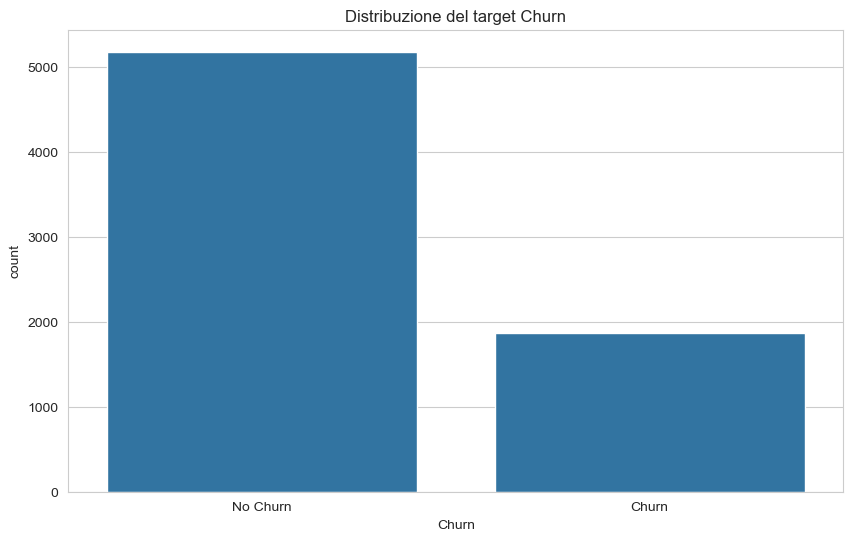

In [15]:
# Conteggio classi
print(df["Churn"].value_counts())

# Percentuali
print("\nPercentuali:")
print(df["Churn"].value_counts(normalize=True) * 100)

# Grafico
sns.countplot(data=df, x="Churn")
plt.title("Distribuzione del target Churn")
plt.xticks([0, 1], ["No Churn", "Churn"])
plt.show()

In [17]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2281.916928,0.265370
std,0.368612,24.559481,30.090047,2265.270398,0.441561
min,0.000000,0.000000,18.250000,18.800000,0.000000
25%,0.000000,9.000000,35.500000,402.225000,0.000000
50%,0.000000,29.000000,70.350000,1397.475000,0.000000
75%,0.000000,55.000000,89.850000,3786.600000,1.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000


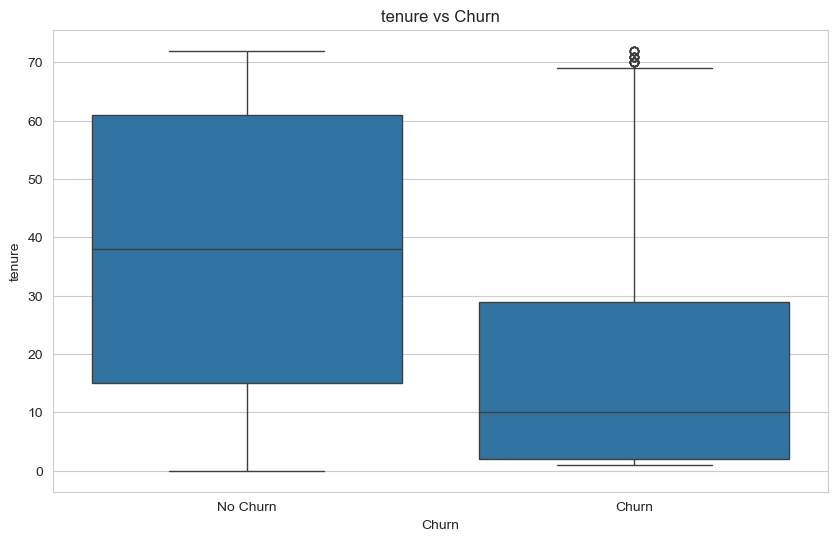

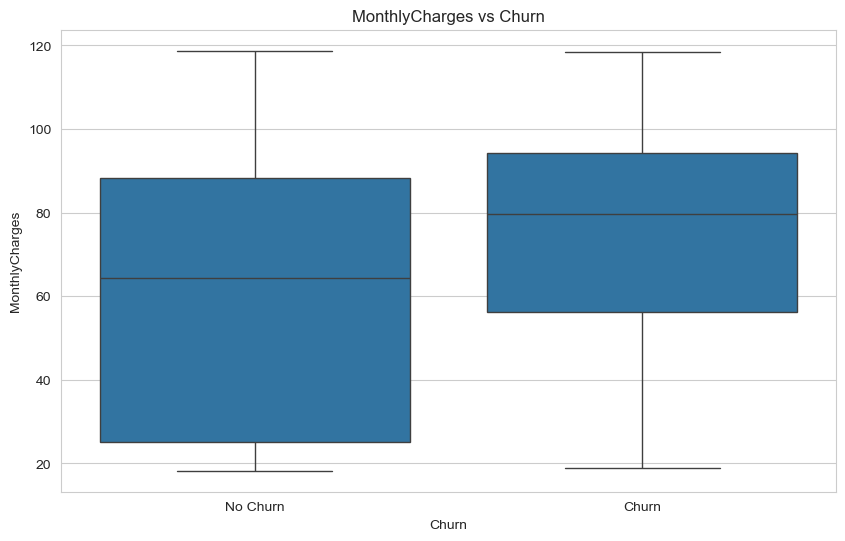

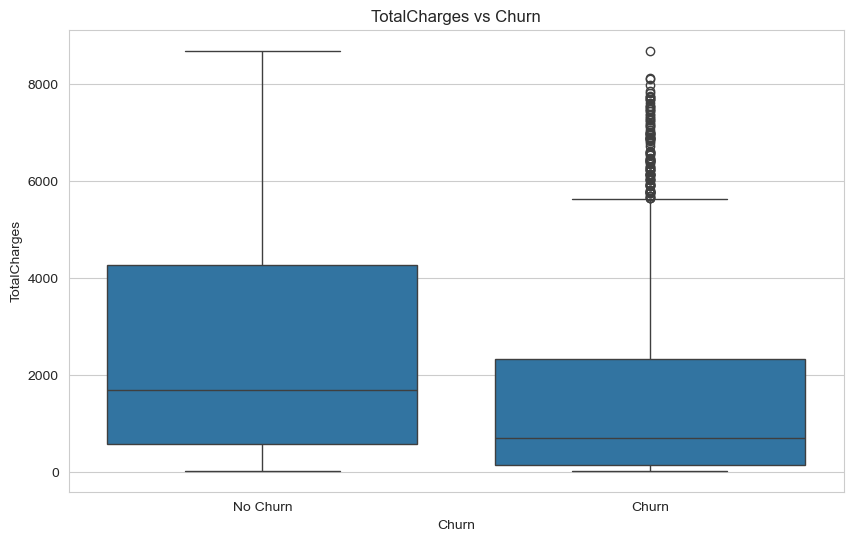

In [19]:
# Vediamo come cambiano variabili numeriche rispetto al churn
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

for col in numeric_cols:
    plt.figure()
    sns.boxplot(data=df, x="Churn", y=col)
    plt.title(f"{col} vs Churn")
    plt.xticks([0, 1], ["No Churn", "Churn"])
    plt.show()

In [ ]:
""" Analisi delle variabili numeriche rispetto al churn

I boxplot mostrano la distribuzione delle principali variabili numeriche separando i clienti che hanno effettuato churn da quelli che non hanno abbandonato il servizio.

Osservazioni principali:

- **Tenure**: i clienti che rimangono nel servizio tendono ad avere una tenure più alta. Al contrario, molti clienti che effettuano churn hanno una permanenza più breve. Questo suggerisce che i nuovi clienti sono più a rischio di abbandono.
  
- **MonthlyCharges**: i clienti con churn sembrano avere in media costi mensili leggermente più elevati. Questo potrebbe indicare che prezzi più alti aumentano la probabilità di abbandono.

- **TotalCharges**: i clienti che non effettuano churn hanno generalmente una spesa totale maggiore, probabilmente perché sono rimasti più a lungo nel servizio.

In generale, la **tenure emerge come una delle variabili più informative**, suggerendo che la durata del rapporto con il cliente è un fattore chiave nella probabilità di churn."""

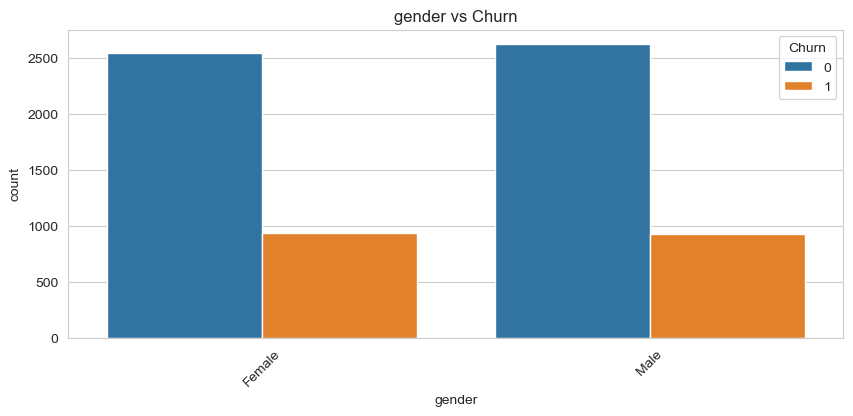

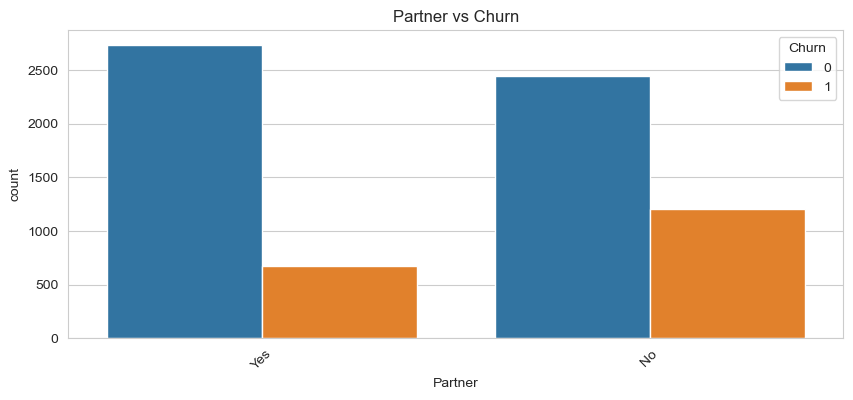

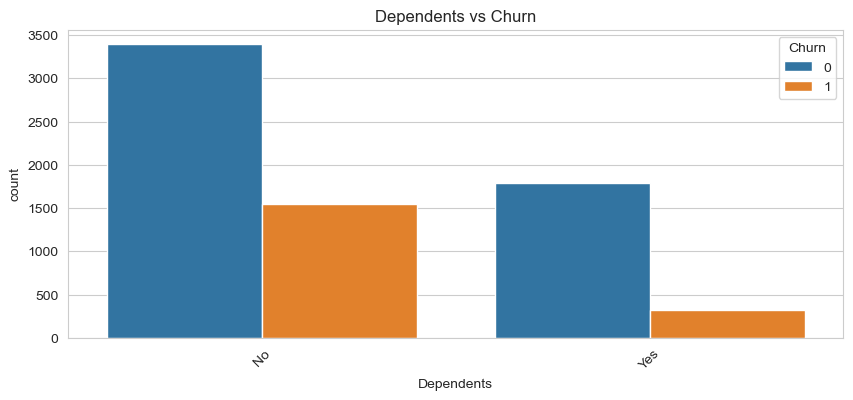

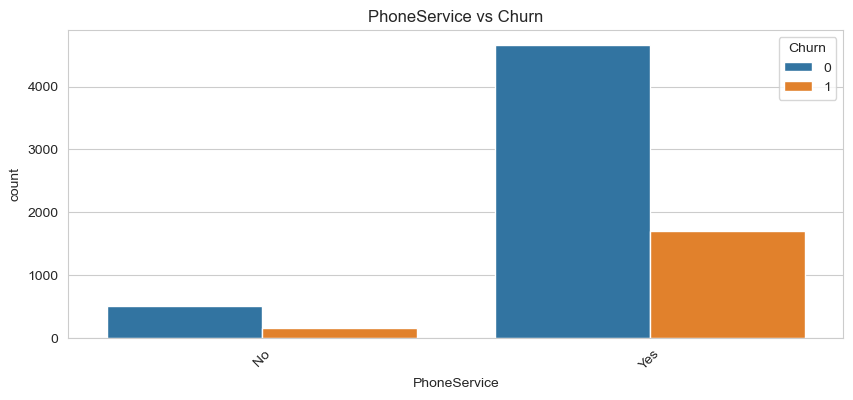

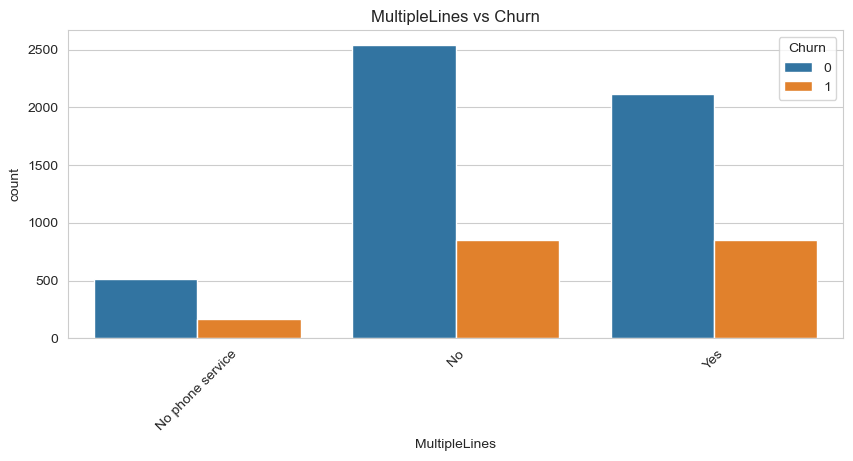

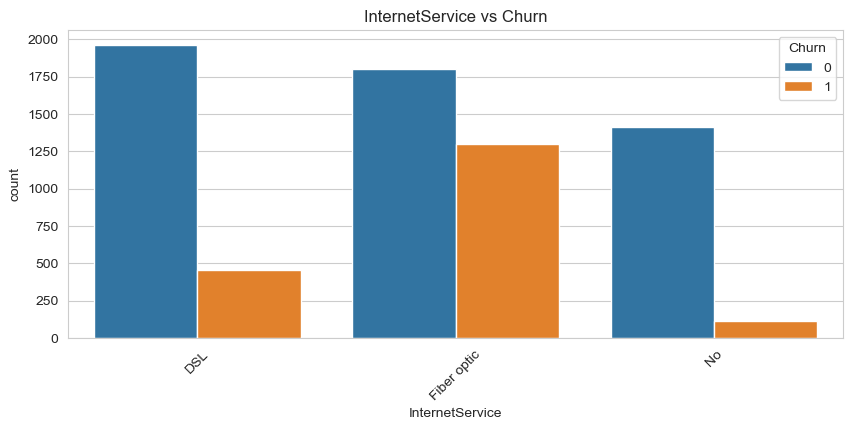

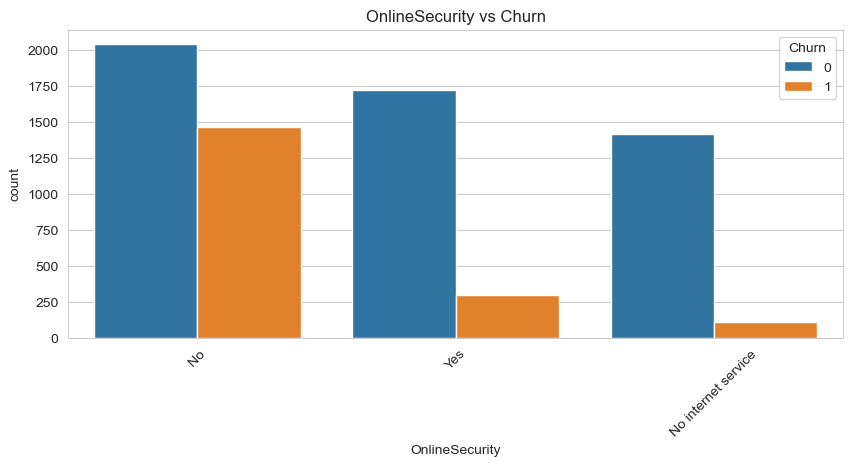

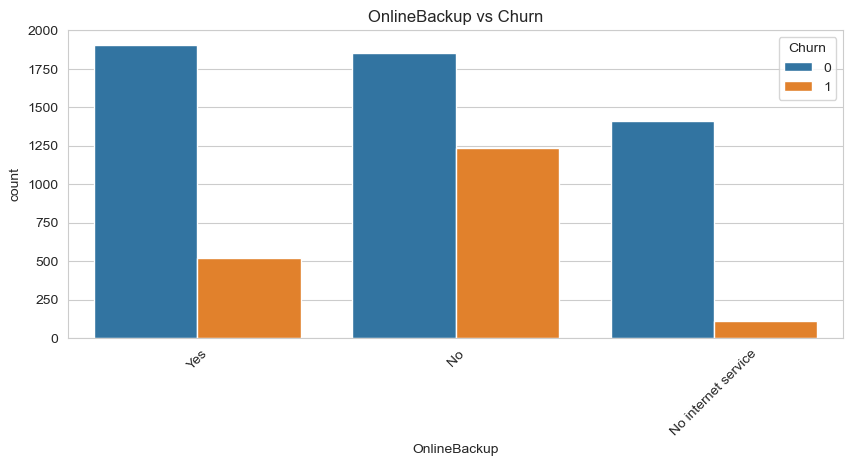

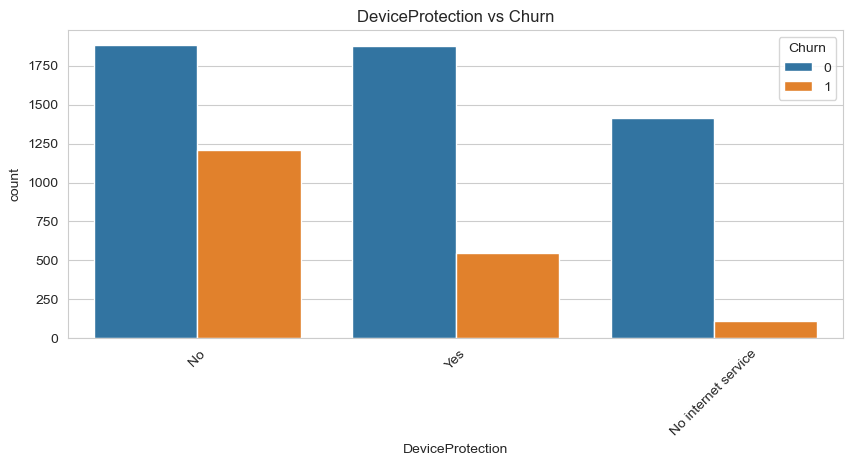

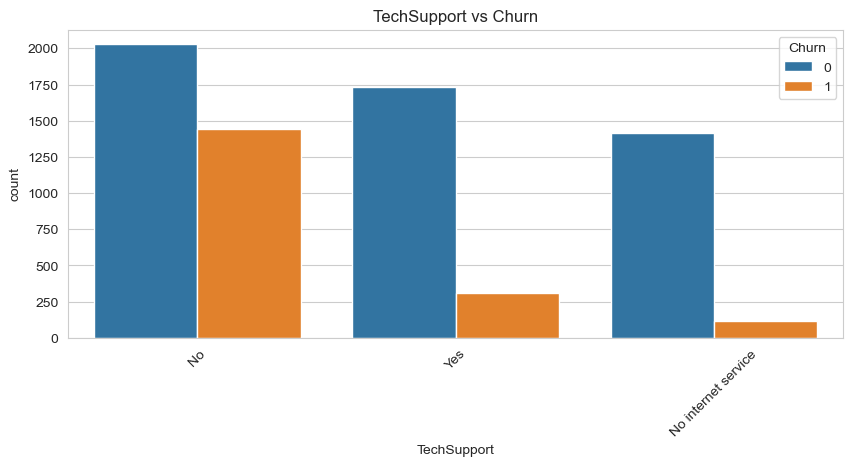

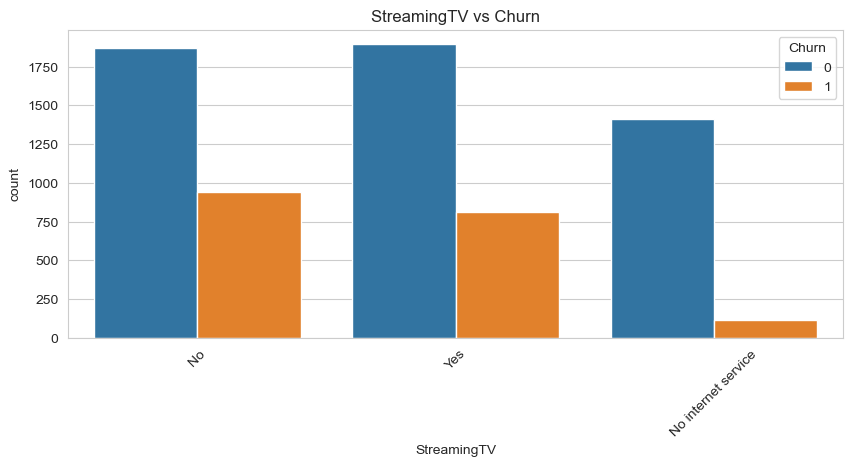

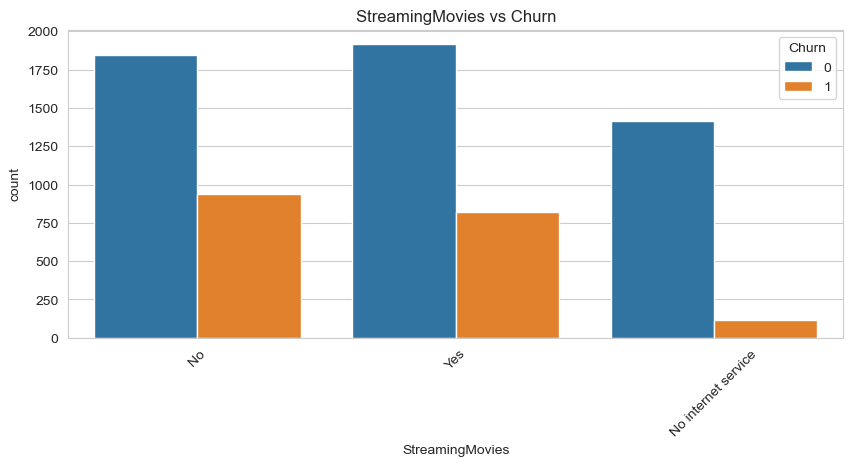

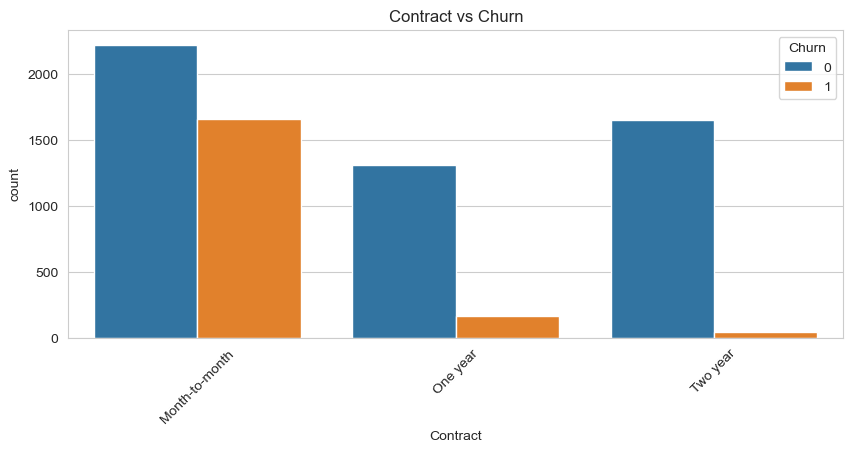

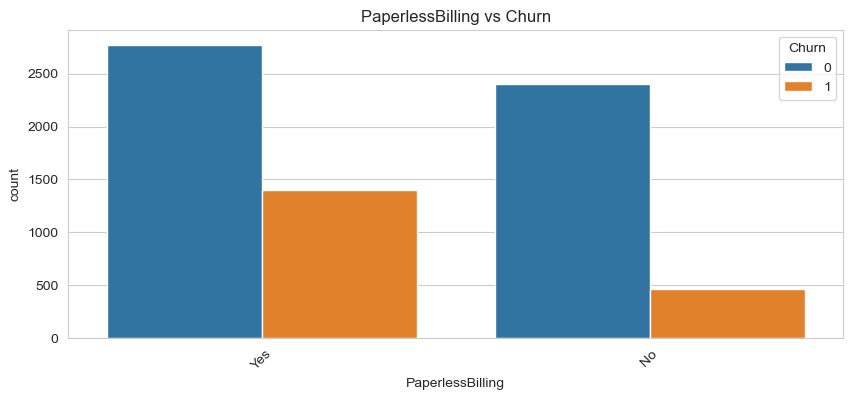

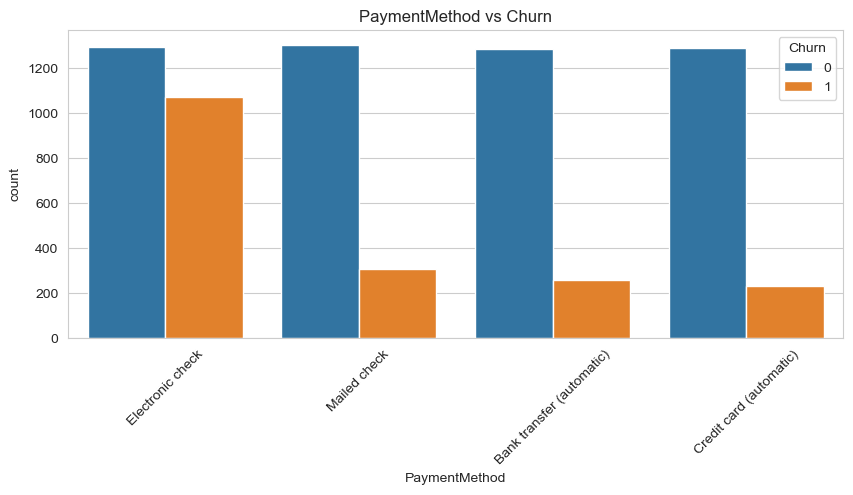

In [21]:
# Serve per vedere quali categorie sono più legate al churn
categorical_cols = df.select_dtypes(include="object").columns.tolist()

for col in categorical_cols:
    plt.figure(figsize=(10, 4))
    sns.countplot(data=df, x=col, hue="Churn")
    plt.title(f"{col} vs Churn")
    plt.xticks(rotation=45)
    plt.show()

In [ ]:
""" Key Insights from Categorical Features

Dall'analisi delle variabili categoriche emergono alcuni pattern interessanti legati al churn.

Il **tipo di contratto (Contract)** risulta essere uno dei fattori più rilevanti. I clienti con contratto **month-to-month** mostrano una percentuale di churn molto più elevata rispetto a quelli con contratti annuali o biennali. Questo suggerisce che contratti più lunghi favoriscono la fidelizzazione dei clienti.

Anche alcuni **servizi aggiuntivi** sembrano influenzare il comportamento dei clienti. In particolare, i clienti senza **OnlineSecurity** o **TechSupport** mostrano una probabilità di churn significativamente più alta. Questo indica che i servizi di supporto e sicurezza possono contribuire ad aumentare il valore percepito del servizio.

Il **tipo di connessione Internet** mostra inoltre alcune differenze: i clienti con **Fiber optic** sembrano avere una percentuale di churn più elevata rispetto ad altre tipologie di connessione.

Infine, il **metodo di pagamento** evidenzia un pattern interessante: i clienti che utilizzano **Electronic Check** presentano una percentuale di churn più alta rispetto a quelli con pagamenti automatici.

Nel complesso, queste osservazioni suggeriscono che fattori come **struttura del contratto, servizi aggiuntivi e modalità di pagamento** possono giocare un ruolo importante nel comportamento di abbandono dei clienti."""

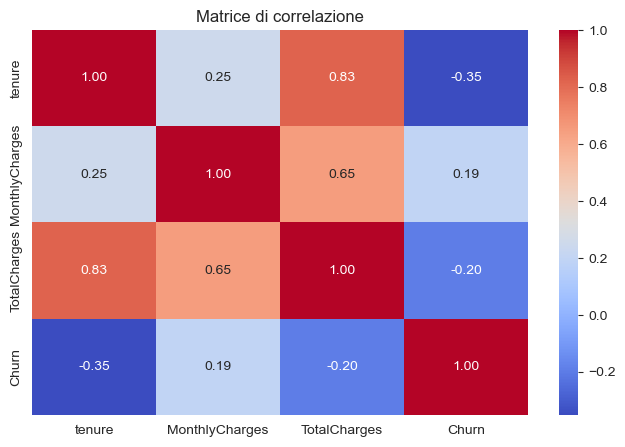

In [23]:
# Correlazione tra feature numeriche
plt.figure(figsize=(8, 5))
sns.heatmap(df[["tenure", "MonthlyCharges", "TotalCharges", "Churn"]].corr(),
            annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matrice di correlazione")
plt.show()

In [ ]:
""" Interpretazione della matrice di correlazione

La matrice di correlazione mostra la relazione lineare tra le variabili numeriche del dataset.

Osservazioni principali:
- **tenure** ha una correlazione negativa con **Churn** (`-0.35`): i clienti con maggiore anzianità tendono ad abbandonare meno il servizio.
- **MonthlyCharges** ha una correlazione positiva ma debole con **Churn** (`0.19`): clienti con costi mensili più alti sembrano avere una probabilità leggermente maggiore di churn.
- **TotalCharges** ha una correlazione negativa debole con **Churn** (`-0.20`), probabilmente perché clienti con più anzianità accumulano più spesa totale e tendono anche a restare.
- **tenure** e **TotalCharges** sono fortemente correlate (`0.83`), cosa abbastanza attesa: più tempo un cliente rimane, più spesa totale accumula.

In generale, la correlazione lineare aiuta a individuare pattern iniziali, ma non basta da sola per spiegare completamente il churn, soprattutto in presenza di variabili categoriche e relazioni non lineari."""

In [25]:
# X = variabili indipendenti
X = df.drop(columns=["Churn"])

# y = variabile target
y = df["Churn"]

print("Shape X:", X.shape)
print("Shape y:", y.shape)

Shape X: (7043, 19)
Shape y: (7043,)


In [27]:
# Divido in train e test e uso stratify per mantenere le proporzioni del target
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Shape X_train:", X_train.shape)
print("Shape X_test:", X_test.shape)
print("Distribuzione y_train:\n", y_train.value_counts(normalize=True))
print("Distribuzione y_test:\n", y_test.value_counts(normalize=True))

Shape X_train: (5634, 19)
Shape X_test: (1409, 19)
Distribuzione y_train:
 Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64
Distribuzione y_test:
 Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


In [29]:
# Colonne numeriche
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Colonne categoriche
categorical_features = X.select_dtypes(include="object").columns.tolist()

print("Colonne numeriche:", numeric_features)
print("Colonne categoriche:", categorical_features)

Colonne numeriche: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Colonne categoriche: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [31]:
# Pipeline numerica:
# 1. imputazione con mediana
# 2. standardizzazione
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Pipeline categorica:
# 1. imputazione con valore più frequente
# 2. one hot encoding
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# ColumnTransformer applica trasformazioni diverse a colonne diverse
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [33]:
# Pipeline completa:
# preprocessing + modello
log_reg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(class_weight="balanced", random_state=42, max_iter=1000))
])

# Addestriamo il modello
log_reg_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [35]:
# Predizioni classe
y_pred_log = log_reg_pipeline.predict(X_test)

# Probabilità della classe positiva
y_proba_log = log_reg_pipeline.predict_proba(X_test)[:, 1]

# Metriche
print("Accuracy:", round(accuracy_score(y_test, y_pred_log), 4))
print("Precision:", round(precision_score(y_test, y_pred_log), 4))
print("Recall:", round(recall_score(y_test, y_pred_log), 4))
print("F1-score:", round(f1_score(y_test, y_pred_log), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_log), 4))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_log))

Accuracy: 0.7381
Precision: 0.5043
Recall: 0.7834
F1-score: 0.6136
ROC-AUC: 0.8413

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [ ]:
""" Valutazione del modello Logistic Regression

La Logistic Regression rappresenta il modello baseline del progetto.

Risultati principali:
- **Accuracy = 0.738**: il modello classifica correttamente circa il 74% dei casi.
- **Recall = 0.783** sulla classe churn: il modello riesce a identificare una buona parte dei clienti che effettivamente abbandonano.
- **Precision = 0.504**: tra i clienti previsti come a rischio churn, circa il 50% abbandona davvero.
- **ROC-AUC = 0.841**: il modello ha una buona capacità di distinguere tra clienti che faranno churn e clienti che resteranno.

Questo risultato è interessante dal punto di vista business: il modello privilegia il recupero dei clienti a rischio (**recall alta**), anche accettando qualche falso positivo in più. In un contesto reale, questo può essere utile quando il costo di perdere un cliente è maggiore del costo di contattare qualcuno in più."""

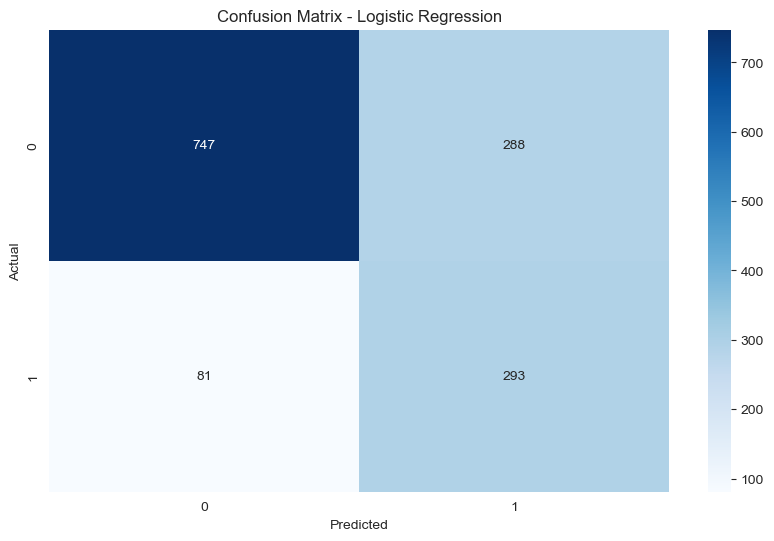

In [37]:
# Capiamo dove sbaglia il modello
cm = confusion_matrix(y_test, y_pred_log)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
""" Interpretazione della confusion matrix

La confusion matrix permette di capire più nel dettaglio dove il modello sbaglia.

Nel nostro caso:
- **747 True Negatives**: clienti correttamente classificati come non a rischio churn.
- **293 True Positives**: clienti correttamente classificati come churn.
- **288 False Positives**: clienti previsti come churn ma che in realtà non abbandonano.
- **81 False Negatives**: clienti che abbandonano davvero ma che il modello non riesce a intercettare.

Dal punto di vista pratico, i **false negatives** sono spesso l’errore più costoso, perché rappresentano clienti persi senza alcun intervento preventivo. In questo caso il numero di false negatives è relativamente contenuto, segnale che il modello riesce a catturare una buona quota dei clienti a rischio."""

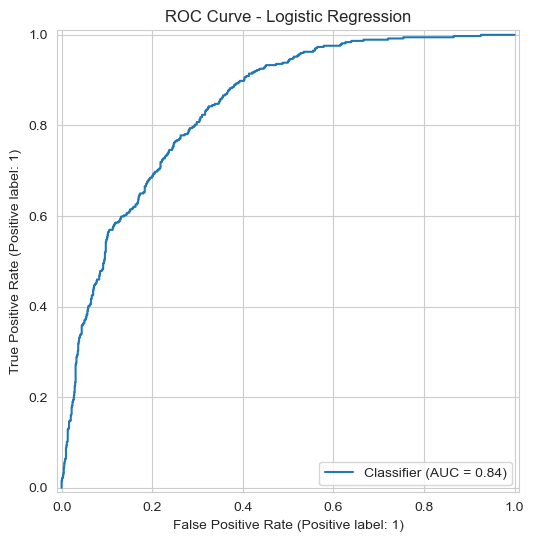

In [39]:
RocCurveDisplay.from_predictions(y_test, y_proba_log)
plt.title("ROC Curve - Logistic Regression")
plt.show()

In [ ]:
""" Interpretazione della ROC Curve

La ROC Curve mostra la capacità del modello di separare le due classi al variare della soglia di classificazione.

L'**AUC = 0.84** indica una buona capacità discriminante: il modello distingue in modo efficace tra clienti che faranno churn e clienti che non lo faranno.

Una curva vicina all’angolo in alto a sinistra indica una performance migliore, mentre una curva vicina alla diagonale rappresenterebbe un modello quasi casuale. In questo caso, la curva si mantiene ben al di sopra della diagonale, confermando che la Logistic Regression fornisce risultati solidi come baseline."""

In [41]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_split=10,
        min_samples_leaf=4,
        class_weight="balanced",
        random_state=42
    ))
])

# Addestramento
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  [...
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced', max_depth=10,
                                        min_samples_leaf=4,
                                        min_samples_split=10, n_estimators=300,
                                        random_state=42))])

In [43]:
# Predizioni
y_pred_rf = rf_pipeline.predict(X_test)
y_proba_rf = rf_pipeline.predict_proba(X_test)[:, 1]

# Metriche
print("Accuracy:", round(accuracy_score(y_test, y_pred_rf), 4))
print("Precision:", round(precision_score(y_test, y_pred_rf), 4))
print("Recall:", round(recall_score(y_test, y_pred_rf), 4))
print("F1-score:", round(f1_score(y_test, y_pred_rf), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_rf), 4))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.7651
Precision: 0.5421
Recall: 0.7406
F1-score: 0.626
ROC-AUC: 0.8415

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.77      0.83      1035
           1       0.54      0.74      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.77      1409



In [ ]:
""" Valutazione del modello Random Forest

La Random Forest migliora leggermente alcuni risultati rispetto alla Logistic Regression.

Risultati principali:
- **Accuracy = 0.765**
- **Precision = 0.542**
- **Recall = 0.741**
- **F1-score = 0.626**
- **ROC-AUC = 0.842**

Rispetto al modello baseline, la Random Forest ottiene una **accuracy leggermente più alta** e una **precision migliore**, mentre la recall scende leggermente. Questo significa che il modello è un po’ più equilibrato e meno aggressivo nel segnalare churn, riducendo alcuni falsi allarmi.

Nel complesso, le performance dei due modelli sono molto vicine, ma la Random Forest risulta leggermente migliore in termini complessivi di robustezza e capacità predittiva."""

In [45]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_rf)
    ],
    "F1": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_rf)
    ],
    "ROC_AUC": [
        roc_auc_score(y_test, y_proba_log),
        roc_auc_score(y_test, y_proba_rf)
    ]
})

results.sort_values(by="ROC_AUC", ascending=False)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
1,Random Forest,0.765082,0.542074,0.740642,0.625989,0.841454
0,Logistic Regression,0.738112,0.504303,0.783422,0.613613,0.841298


In [ ]:
""" Confronto tra i modelli

Il confronto finale mostra che entrambi i modelli ottengono buone performance, ma con un comportamento leggermente diverso:

- La **Logistic Regression** ha una **recall più alta**, quindi intercetta meglio i clienti a rischio churn.
- La **Random Forest** offre una **precision e accuracy leggermente superiori**, risultando più bilanciata.
- Il valore di **ROC-AUC** è quasi identico per entrambi, segno che i modelli hanno una capacità discriminante molto simile.

La scelta del modello migliore dipende quindi anche dall’obiettivo di business:
- se vogliamo intercettare il maggior numero possibile di clienti a rischio, possiamo preferire la **Logistic Regression**;
- se vogliamo un modello più equilibrato e leggermente più accurato, possiamo preferire la **Random Forest**.

In questo progetto, la **Random Forest** viene selezionata come modello finale."""

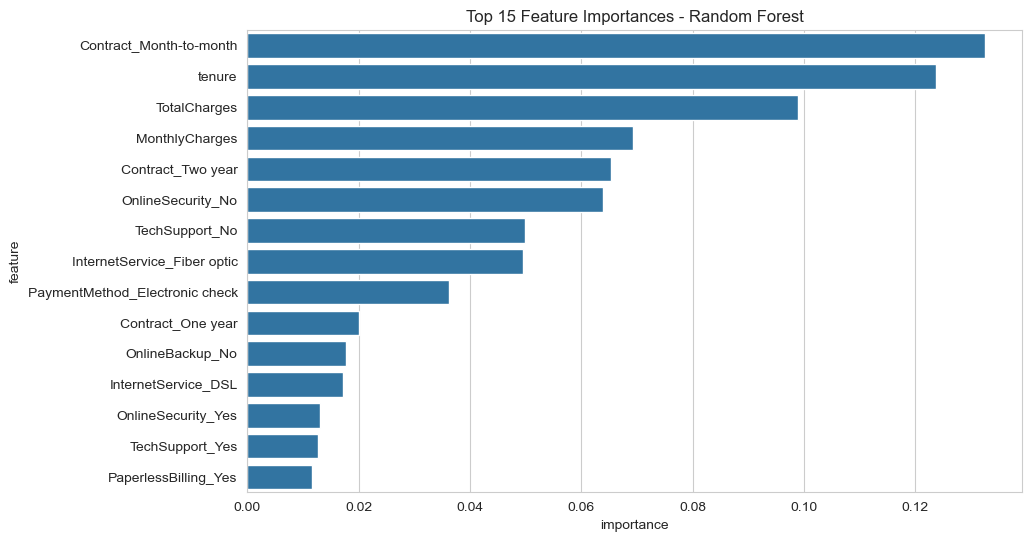

In [47]:
# Recuperiamo il preprocessore già addestrato
fitted_preprocessor = rf_pipeline.named_steps["preprocessor"]

# Otteniamo i nomi finali delle feature dopo one-hot encoding
encoded_cat_features = fitted_preprocessor.named_transformers_["cat"] \
    .named_steps["onehot"] \
    .get_feature_names_out(categorical_features)

all_feature_names = numeric_features + list(encoded_cat_features)

# Recuperiamo l'importanza delle feature dal modello
importances = rf_pipeline.named_steps["classifier"].feature_importances_

# Creiamo dataframe ordinato
feature_importance_df = pd.DataFrame({
    "feature": all_feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

# Mostriamo le top 15
top_15 = feature_importance_df.head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_15, x="importance", y="feature")
plt.title("Top 15 Feature Importances - Random Forest")
plt.show()

In [ ]:
""" Interpretazione delle feature importance

Il grafico delle feature importance mostra quali variabili incidono maggiormente nelle decisioni del modello Random Forest.

Le feature più rilevanti risultano essere:
- **Contract_Month-to-month**
- **tenure**
- **TotalCharges**
- **MonthlyCharges**
- alcune variabili legate ai servizi aggiuntivi, come **OnlineSecurity** e **TechSupport**

Questi risultati suggeriscono che il churn è fortemente influenzato da:
1. **tipo di contratto**: i clienti con contratto mensile sono più instabili;
2. **anzianità del cliente**: chi è cliente da meno tempo tende ad abbandonare più facilmente;
3. **spesa e caratteristiche del servizio**: costo mensile, spesa totale e servizi di supporto sembrano avere un ruolo importante.

Dal punto di vista business, questi insight possono aiutare a progettare strategie di retention più mirate, ad esempio offerte dedicate ai clienti con contratto month-to-month o con bassa anzianità."""

In [49]:
best_model = results.sort_values(by="ROC_AUC", ascending=False).iloc[0]["Model"]

print("Miglior modello in base al ROC-AUC:", best_model)
print("\nTop 10 feature più importanti:")
print(feature_importance_df.head(10))

Miglior modello in base al ROC-AUC: Random Forest

Top 10 feature più importanti:
                           feature  importance
36         Contract_Month-to-month    0.132638
1                           tenure    0.123687
3                     TotalCharges    0.098975
2                   MonthlyCharges    0.069352
38               Contract_Two year    0.065384
18               OnlineSecurity_No    0.063890
27                  TechSupport_No    0.049824
16     InternetService_Fiber optic    0.049502
43  PaymentMethod_Electronic check    0.036218
37               Contract_One year    0.020139


In [ ]:
""" Conclusione finale

L’analisi mostra che il churn può essere previsto con buoni risultati usando sia modelli lineari sia modelli ad albero.

La **Random Forest** è stata scelta come modello finale perché ottiene le performance migliori nel confronto complessivo e permette anche di individuare con chiarezza le variabili più importanti.

Tra i principali fattori associati al churn emergono:
- contratti mensili,
- bassa anzianità del cliente,
- costi mensili più elevati,
- assenza di alcuni servizi di supporto e sicurezza.
"""

In [51]:
import joblib
import os

# Creiamo la cartella models se non esiste
os.makedirs("models", exist_ok=True)

# Salviamo il modello Random Forest
joblib.dump(rf_pipeline, "models/telco_churn_random_forest.pkl")

print("Modello salvato correttamente.")

Modello salvato correttamente.
